In [2]:
import pandas as pd

In [4]:
insurance = pd.read_csv("F://Insurance_charges//Data//insurance.csv")

In [6]:
insurance_df = insurance.copy()

In [7]:
insurance_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [8]:
insurance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [9]:
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
insurance_df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

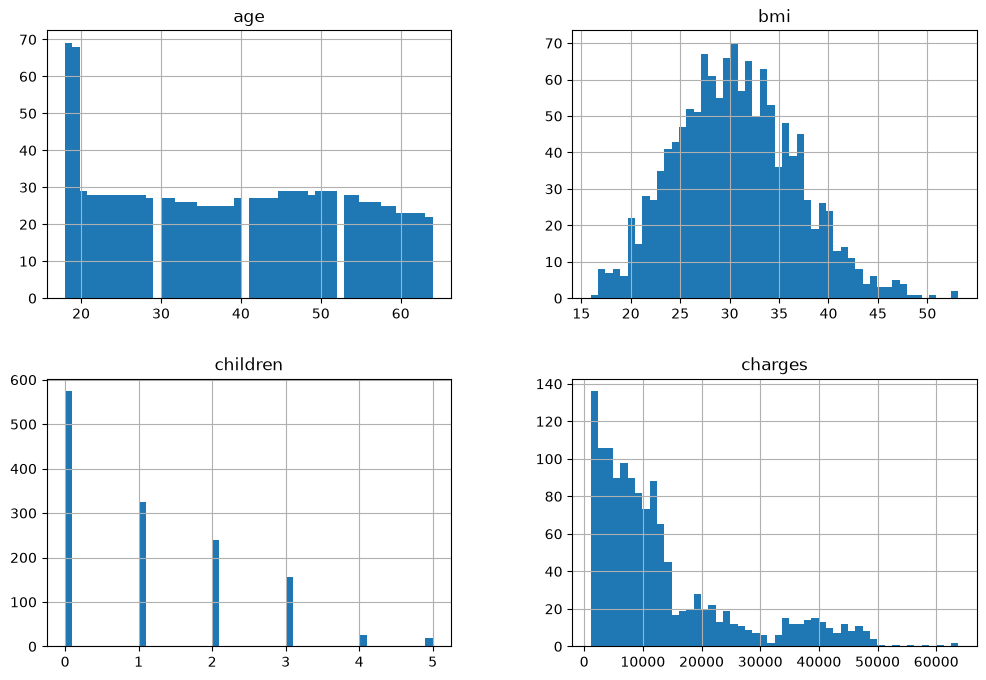

In [15]:
import matplotlib.pyplot as plt

insurance_df.hist(bins=50, figsize=(12, 8))
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

insurance_train , insurance_test = train_test_split(insurance_df , test_size=0.3 , stratify=insurance_df["smoker"] , random_state=42)

In [18]:
insurance_t = insurance_train.copy()

In [21]:
value_map = {
    "male" : 1,
    "female" : 0,
    "yes" : 1,
    "no" : 0
}

In [22]:
insurance_t["sex"] = insurance_t["sex"].map(value_map)
insurance_t["smoker"] = insurance_t["smoker"].map(value_map)

In [25]:
from sklearn.preprocessing import OneHotEncoder

In [26]:
insurance_t = pd.get_dummies(insurance_t, columns=["region"], drop_first=True, dtype=int)

In [27]:
insurance_t.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
1202,22,1,32.110,0,0,2055.32490,1,0,0
1244,18,1,33.330,0,0,1135.94070,0,1,0
1001,24,1,32.700,0,1,34472.84100,0,0,1
239,44,1,38.060,1,0,7152.67140,0,1,0
24,37,1,28.025,2,0,6203.90175,1,0,0


In [28]:
corr_matrix = insurance_t.corr(numeric_only=True)

In [29]:
corr_matrix["charges"].sort_values(ascending = False)

charges             1.000000
smoker              0.786884
age                 0.289361
bmi                 0.184683
children            0.067377
region_southeast    0.059213
sex                 0.046354
region_southwest   -0.025748
region_northwest   -0.060359
Name: charges, dtype: float64

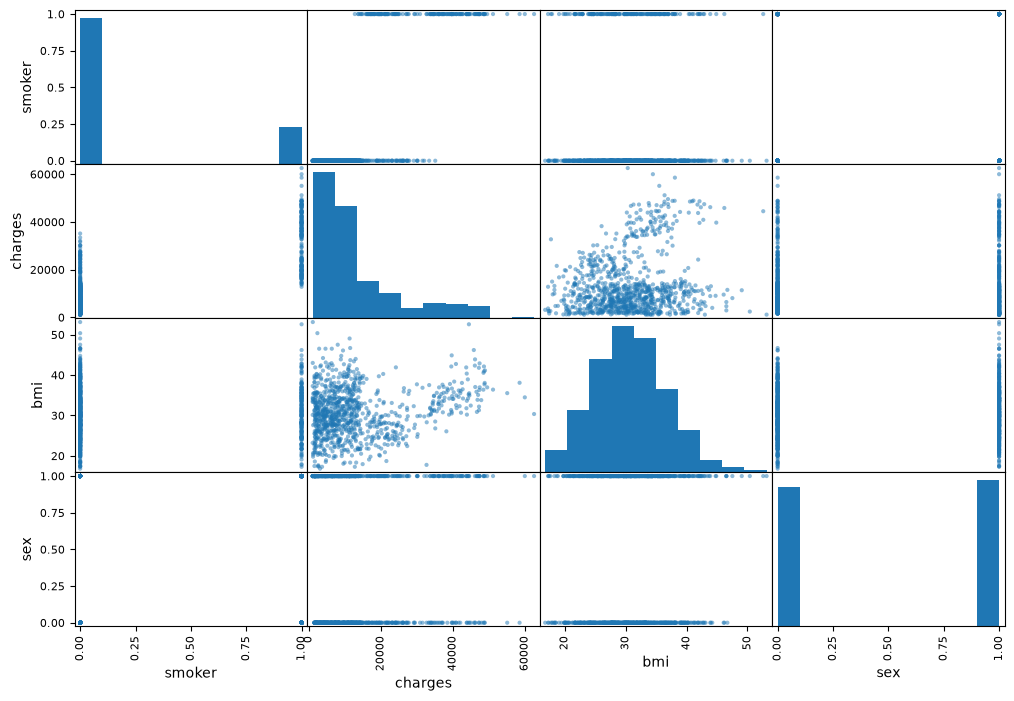

In [31]:
from pandas.plotting import scatter_matrix

attributes = ["smoker" , "charges" , "bmi", "sex"]
scatter_matrix(insurance_t[attributes] , figsize=(12, 8))
plt.show()

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [43]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

num_columns = ["age", "bmi", "children"]
ohe_column = ["region"]
ordinal_columns = ["sex", "smoker"]

preprocessing = ColumnTransformer([
    ("num", "passthrough", num_columns),
    ("ohe", OneHotEncoder(drop='first'), ohe_column),
    ("ordinal", OrdinalEncoder(categories=[['female','male'], ['no','yes']]), ordinal_columns),
])

In [45]:
X = insurance_train.drop(columns=["charges"])
y = insurance_train["charges"]

In [46]:
from sklearn.linear_model import LinearRegression

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", LinearRegression())
])

full_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated wit

In [47]:
X_test = insurance_test.drop(columns=["charges"])
y_test = insurance_test["charges"]

In [48]:
prediction = full_pipeline.predict(X_test)

In [49]:
from sklearn.metrics import root_mean_squared_error

linear_rmse = root_mean_squared_error(y_test , prediction)
linear_rmse

5828.218276871837